In [100]:
import numpy as np
import matplotlib.pyplot as plt

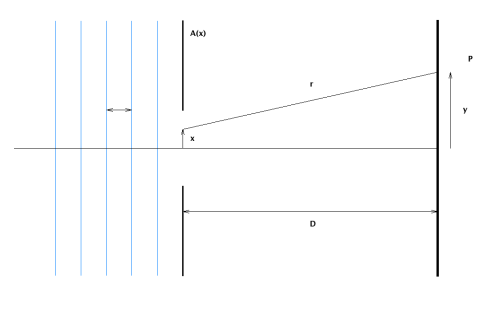

In [101]:
from IPython.display import Image
Image("setup_diagram.png")

In [102]:
def diffract(A_, N):
    """
    Function taking in a complex aperture function as an array A_, the number of 
    sampling points N, and returns the relative diffracted intensities I and their 
    physical coordinates y as a tuple (y, I)
    """
    dx = L/N
    # Calculating Fourier transformed intensity from aperture A_
    psi = np.fft.fft(A_)
    psi = np.fft.fftshift(psi)
    I = abs(psi)**2
    I = I/I.max()

    # Generating an array of correctly ordered 'frequency' i.e. q = ky/D components
    q = np.fft.fftfreq(N, dx)
    q = np.fft.fftshift(q)

    # Calculating the actual y on screen for each frequency value
    y = q*D/k *2*np.pi

    return (y, I)

# <b> Core task 1 </b>: Far field single clear slit

In [103]:
# Define parameters
lmd = 500.0e-9
k = 2*np.pi/lmd
d = 100.0e-6
D = 1.0
L = 50*d

N = 2**14

# Ratio of distance to Fresnel distance
ratio = D/(d**2/lmd)
ratio

50.0

In [104]:
def single_slit(d, L, N):
    """
    Function returning the arrays (A_, x, A) for a single clear slit of width d 
    and total extent L, with N sampling points
    """
    # Initialise x values and create aperture, including the near-field phase
    x = np.linspace(-L/2, L/2, N)
    A = np.zeros_like(x)
    A[(x > -d/2) & (x < d/2)] = 1.0
    A_ = np.exp(1j*k*x**2/(2*D))*A

    # Return x and the unmodified and modified aperture functions
    return (A_, x, A)

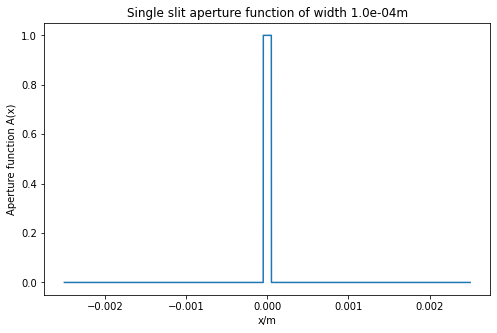

In [105]:
# Create aperture
A_, x, A = single_slit(d, L, N)

# Plot the unmodified aperture
plt.plot(x, A)
plt.title(f"Single slit aperture function of width {d:.1e}m")
plt.xlabel("x/m")
plt.ylabel("Aperture function A(x)");

In [106]:
# Calculating Fourier transformed intensity
y, I_ft = diffract(A_, N)

# Calculating the expected pattern working by hand
psi_ex = np.sinc((k*d*y/(2*D))/np.pi)
I_ex = abs(psi_ex)**2

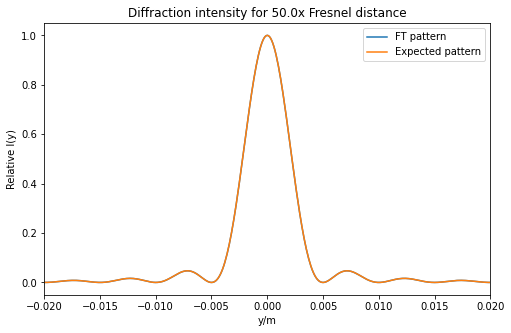

In [107]:
# Plotting the FT diffraction pattern and the expected pattern
plt.plot(y, I_ft, label="FT pattern")
plt.plot(y, I_ex, label="Expected pattern")
plt.xlim(-0.02,0.02)
plt.xlabel("y/m")
plt.ylabel("Relative I(y)")  
plt.title(f"Diffraction intensity for {ratio}x Fresnel distance")
plt.legend();

# <b> Core task 2 </b>: Sinusoidal phase grating

In [108]:
# Define new parameters
d = 2.0e-3
L = 50*d
s = 100e-6
m = 8
D = 10.0
N = 2**15

# Ratio of distance to Fresnel distance
ratio = D/(d**2/lmd)
ratio

1.25

In [109]:
def sin_grating(d, L, N):
    """
    Function returning a sinusoidal phase grating
    Inputs: grating width d, total extent L, sampling points N
    Returns: modified near-field grating array A_, sample array x, unmodified far-
    field array A as tuple (A_, x, A)
    """
    x = np.linspace(-L/2, L/2, N)
    A = np.zeros_like(x, dtype='complex')
    # Set phase for |x| < d/2
    grating_range = (x>-d/2) & (x<d/2)
    A[grating_range] = np.exp(1j * (m/2) * np.sin(2*np.pi*x[grating_range]/s))
    # Modified near-field array
    A_ = np.exp(1j*k*x**2/(2*D))*A
    return (A_, x, A)

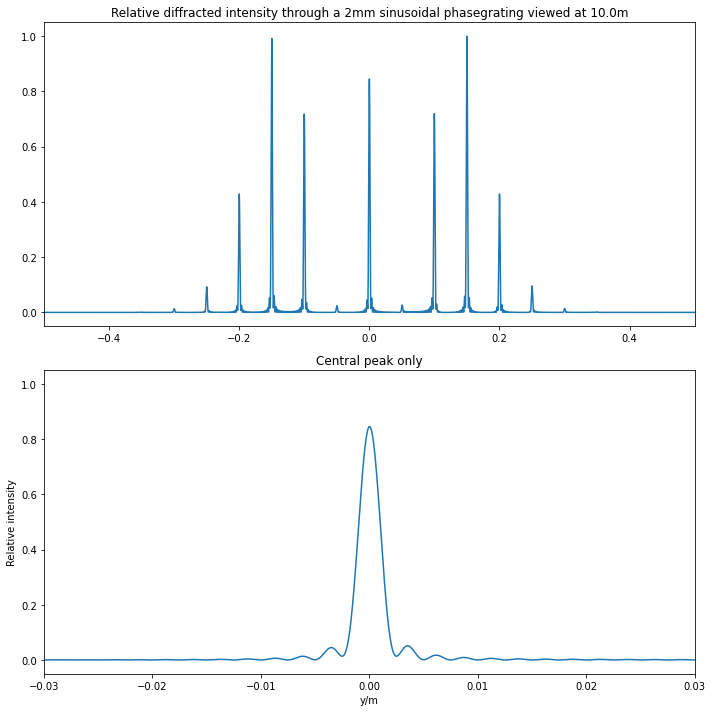

In [110]:
# Create aperture, diffract and plot
L = 50*d
A_, x, A = sin_grating(d, L, N)
y, I = diffract(A_, N)

fig, (ax1, ax2) = plt.subplots(2,1)
fig.set_figheight(10)
fig.set_figwidth(10)
ax1.plot(y, I)
ax1.set_xlim(-0.5, 0.5)
ax2.plot(y, I)
ax2.set_xlim(-0.03, 0.03)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
ax1.set_title("Relative diffracted intensity through a 2mm sinusoidal phase\
grating viewed at 10.0m")
ax2.set_title("Central peak only")
plt.tight_layout()

Multiplication by the phase function in the aperture results in convolution of the diffraction patterns of the top-hat and the phase function. 
<br>
<br>
The FT of the phase function is a series of modulated delta functions (approximated below by setting L=d i.e. a very long grating with no obstructions), so its convolution with the transforms of the top-hat (sinc) does indeed give the intensities shown above.

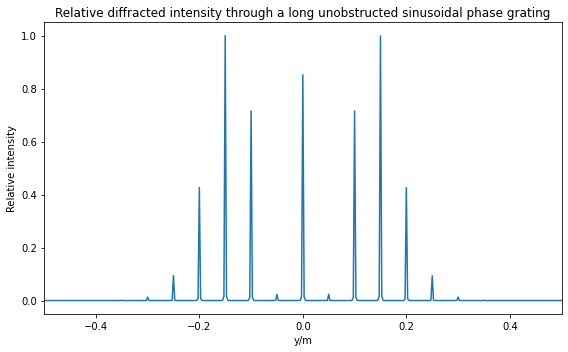

In [111]:
# Long unobstructed grating
L = d
A_, x, A = sin_grating(d, L, N)
y, I = diffract(A_, N)

plt.plot(y, I)
plt.rcParams["figure.figsize"] = (8,5)
plt.xlim(-0.5, 0.5)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
plt.title(f"Relative diffracted intensity through a long unobstructed sinusoidal phase grating")
plt.tight_layout();

# <b> Core task 3 </b>: Near-field pattern

In [112]:
# Redefine parameters for near-field
d = 5.0e-3
D = 0.5
L = 50*d

N = 2**14

# Ratio of distance to Fresnel distance
ratio = D/(d**2/lmd)
ratio


0.009999999999999998

## <b> Task 1 </b>: Single unobstructed slit

In [113]:
# Create aperture
A_ = single_slit(d, L, N)[0]

# Calculate FT intensity
y, I_ft = diffract(A_, N)

# Calculating the expected intensity working by hand
psi_ex = np.sinc((k*d*y/(2*D))/np.pi)
I_ex = abs(psi_ex)**2

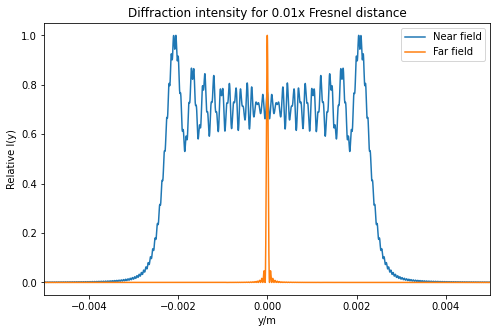

In [114]:
# Plotting the FT diffraction pattern and the expected pattern
plt.plot(y, I_ft, label="Near field")
plt.plot(y, I_ex, label="Far field")
plt.xlim(-0.005,0.005)
plt.xlabel("y/m")
plt.ylabel("Relative I(y)")  
plt.title(f"Diffraction intensity for {ratio:.2}x Fresnel distance")
plt.legend();

Looks sensible, generic near field single-slit diffraction pattern

### Resolution tests

In [115]:
# Calculate FT intensity for single slit
def ss_intensity(d, L, N):
    A_ = single_slit(d, L, N)[0]
    return diffract(A_, N)

In [116]:
y14, I14 = ss_intensity(d, L, 2**14)
y15, I15 = ss_intensity(d, L, 2**15)

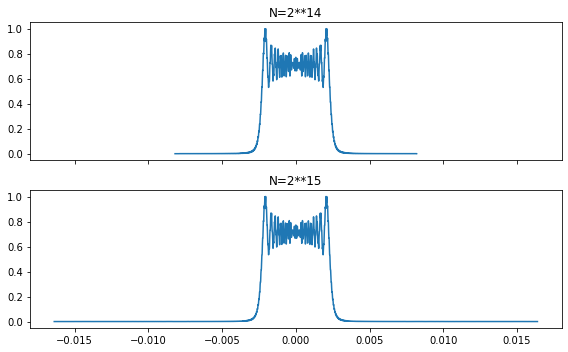

In [117]:
fig, (ax1, ax2) = plt.subplots(2, sharex=True)
ax1.plot(y14, I14)
ax2.plot(y15, I15)
ax1.set_title("N=2**14")
ax2.set_title("N=2**15")
plt.tight_layout()

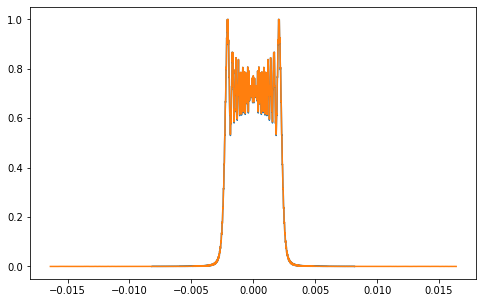

In [118]:
plt.plot(y14, I14)
plt.plot(y15, I15)

## <b>Task 2</b>: Sinusoidal phase grating

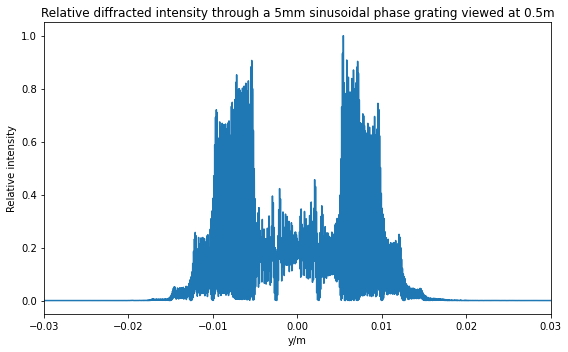

In [119]:
# Create aperture, diffract and plot
L = 50*d
N = 2**17
A_, x, A = sin_grating(d, L, N)
y, I = diffract(A_, N)

plt.plot(y, I)
plt.xlim(-0.03, 0.03)
plt.xlabel("y/m")
plt.ylabel("Relative intensity")
plt.title("Relative diffracted intensity through a 5mm sinusoidal phase \
grating viewed at 0.5m")
plt.tight_layout()

Looks very interesting, seems perhaps to be some convolution of the single-slit near field pattern and some delta functions - difficult to determine from the many terms in the integral. Very cool though!

# <b> Supplementary task </b>: Multiple clear slits

In [120]:
# Define paremeters
d = 100.0e-6
a = 200.0e-6
D = 5.0e-3
L = 50*d

N = 2**15

ratio = D/(d**2/lmd)
ratio

0.25

In [121]:
def two_slit(d, a, L, N):
    """
    Function to create two slit aperture function
    Inputs: slit width d, slit spacing a, window length L, no. of sample points N
    Returns: near field A_(x), window x, far field A(x) as tuple (A_, x, A)
    """
    x = np.linspace(-L/2, L/2, N)
    A = np.zeros_like(x)
    A[abs(x-a/2) < d/2] = 1.0
    A[abs(x+a/2) < d/2] = 1.0
    A_ = A * np.exp(1j*k*x**2/(2*D))
    return (A_, x, A)

def three_slit(d, a, L, N):
    """
    Function to create three slit aperture function
    Inputs: slit width d, slit spacing a, window length L, no. of sample points N
    Returns: near field A_(x), window x, far field A(x) as tuple (A_, x, A)
    """
    x = np.linspace(-L/2, L/2, N)
    A = np.zeros_like(x)
    A[abs(x) < d/2] = 1.0
    A[abs(x-a) < d/2] = 1.0
    A[abs(x+a) < d/2] = 1.0
    A_ = A * np.exp(1j*k*x**2/(2*D))
    return (A_, x, A)

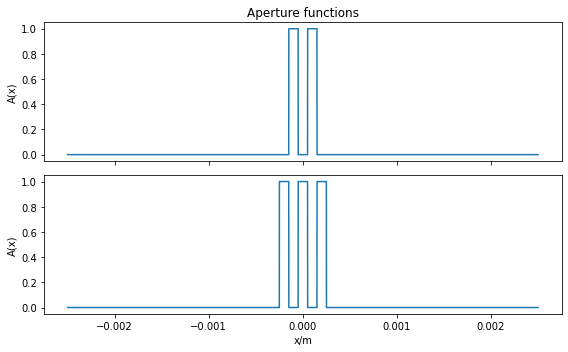

In [122]:
# Create and plot two/three slit aperture functions
A_2, x2, A2 = two_slit(d, a, L, N)
A_3, x3, A3 = three_slit(d, a, L, N)

fig, (ax2, ax3) = plt.subplots(2,1, sharex=True)
ax2.plot(x2, A2)
ax3.plot(x3, A3)
ax2.set_title("Aperture functions")
ax2.set_ylabel("A(x)")
ax3.set_ylabel("A(x)")
plt.xlabel("x/m")
plt.tight_layout()

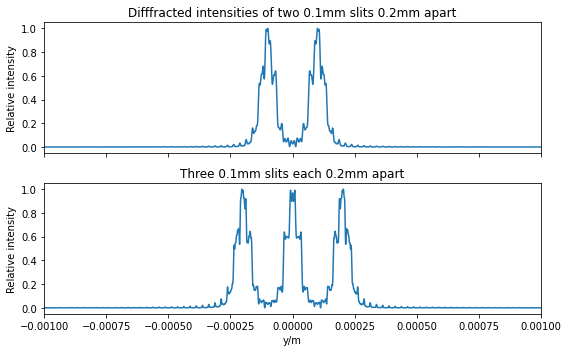

In [123]:
# Calculate and plot the two/three slit diffracted intensities
y2, I2 = diffract(A_2, N)
y3, I3 = diffract(A_3, N)

fig, (ax2, ax3) = plt.subplots(2,1, sharex=True)
ax2.plot(y2, I2)
ax3.plot(y3, I3)
ax3.set_xlim(-0.001, 0.001)
ax2.set_title("Difffracted intensities of two 0.1mm slits 0.2mm apart")
ax2.set_ylabel("Relative intensity")
ax3.set_title("Three 0.1mm slits each 0.2mm apart")
ax3.set_ylabel("Relative intensity")
plt.xlabel("y/m")
plt.tight_layout()